In [48]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.tools
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn import metrics

df = pd.read_csv('Life Expectancy Data.csv')

# 1. EDA

In [49]:
df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


In [50]:
df.shape

(2864, 21)

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2864 non-null   str    
 1   Region                       2864 non-null   str    
 2   Year                         2864 non-null   int64  
 3   Infant_deaths                2864 non-null   float64
 4   Under_five_deaths            2864 non-null   float64
 5   Adult_mortality              2864 non-null   float64
 6   Alcohol_consumption          2864 non-null   float64
 7   Hepatitis_B                  2864 non-null   int64  
 8   Measles                      2864 non-null   int64  
 9   BMI                          2864 non-null   float64
 10  Polio                        2864 non-null   int64  
 11  Diphtheria                   2864 non-null   int64  
 12  Incidents_HIV                2864 non-null   float64
 13  GDP_per_capita               

In [52]:
df.dtypes

Country                            str
Region                             str
Year                             int64
Infant_deaths                  float64
Under_five_deaths              float64
Adult_mortality                float64
Alcohol_consumption            float64
Hepatitis_B                      int64
Measles                          int64
BMI                            float64
Polio                            int64
Diphtheria                       int64
Incidents_HIV                  float64
GDP_per_capita                   int64
Population_mln                 float64
Thinness_ten_nineteen_years    float64
Thinness_five_nine_years       float64
Schooling                      float64
Economy_status_Developed         int64
Economy_status_Developing        int64
Life_expectancy                float64
dtype: object

In [53]:
df.describe()

,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
count,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000
mean,2007.500000,30.363792,42.938268,192.251775,4.820882,84.292598,77.344972,25.032926,86.499651,86.271648,0.894288,11540.924930,36.675915,4.865852,4.899825,7.632123,0.206704,0.793296,68.856075
std,4.610577,27.538117,44.569974,114.910281,3.981949,15.995511,18.659693,2.193905,15.080365,15.534225,2.381389,16934.788931,136.485867,4.438234,4.525217,3.171556,0.405012,0.405012,9.405608
min,2000.000000,1.800000,2.300000,49.384000,0.000000,12.000000,10.000000,19.800000,8.000000,16.000000,0.010000,148.000000,0.080000,0.100000,0.100000,1.100000,0.000000,0.000000,39.400000
25%,2003.750000,8.100000,9.675000,106.910250,1.200000,78.000000,64.000000,23.200000,81.000000,81.000000,0.080000,1415.750000,2.097500,1.600000,1.600000,5.100000,0.000000,1.000000,62.700000
50%,2007.500000,19.600000,23.100000,163.841500,4.020000,89.000000,83.000000,25.500000,93.000000,93.000000,0.150000,4217.000000,7.850000,3.300000,3.400000,7.800000,0.000000,1.000000,71.400000
75%,2011.250000,47.350000,66.000000,246.791375,7.777500,96.000000,93.000000,26.400000,97.000000,97.000000,0.460000,12557.000000,23.687500,7.200000,7.300000,10.300000,0.000000,1.000000,75.400000
max,2015.000000,138.100000,224.900000,719.360500,17.870000,99.000000,99.000000,32.100000,99.000000,99.000000,21.680000,112418.000000,1379.860000,27.700000,28.600000,14.100000,1.000000,1.000000,83.800000


In [54]:
df['Measles'].unique()

array([65, 94, 35, 74, 89, 86, 97, 99, 87, 92, 70, 77, 83, 98, 71, 90, 64,
       84, 58, 19, 88, 76, 53, 96, 93, 34, 85, 91, 95, 28, 12, 79, 56, 55,
       57, 38, 48, 33, 81, 47, 78, 80, 60, 63, 39, 44, 82, 61, 66, 42, 52,
       75, 67, 68, 72, 32, 24, 73, 31, 15, 23, 46, 41, 54, 45, 36, 59, 49,
       18, 16, 69, 51, 14, 29, 50, 40, 10, 43, 17, 62, 13, 22, 21, 26, 30,
       25, 27])

In [55]:
c = df.corr(numeric_only=True)
mask = np.triu(np.ones(c.shape), k=1).astype(bool)
pairs = c.where(mask).stack()

pairs[pairs.abs() > 0.75].sort_values(key=abs, ascending=False)

Economy_status_Developed     Economy_status_Developing   -1.000000
Infant_deaths                Under_five_deaths            0.985651
Polio                        Diphtheria                   0.953178
Adult_mortality              Life_expectancy             -0.945360
Thinness_ten_nineteen_years  Thinness_five_nine_years     0.938757
Under_five_deaths            Life_expectancy             -0.920419
Infant_deaths                Life_expectancy             -0.920032
Under_five_deaths            Adult_mortality              0.802361
Infant_deaths                Adult_mortality              0.794661
                             Schooling                   -0.788513
Under_five_deaths            Schooling                   -0.773196
Hepatitis_B                  Diphtheria                   0.761780
dtype: float64

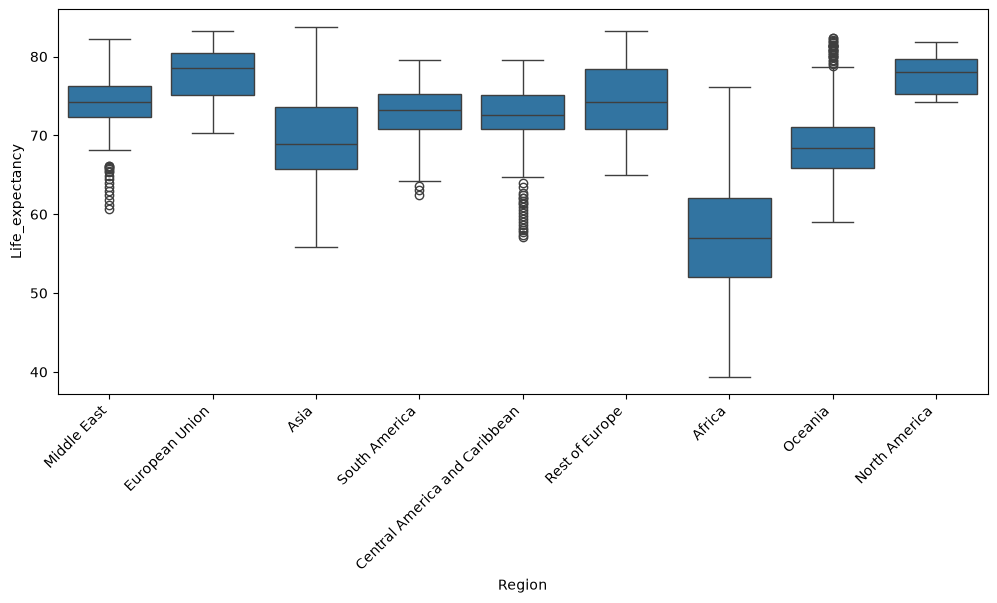

In [56]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Region', y='Life_expectancy')
plt.xticks(rotation=45, ha='right')
plt.show()

In [57]:
obj_cols = df.select_dtypes('object').columns
for c in obj_cols:
    print(f'{c:18s} {df[c].nunique():3d}  {sorted(df[c].unique())[:8]}')

Country            179  ['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia']
Region               9  ['Africa', 'Asia', 'Central America and Caribbean', 'European Union', 'Middle East', 'North America', 'Oceania', 'Rest of Europe']


# 2. Encoding

In [58]:
df_clean = df.copy()
df_clean = pd.get_dummies(df_clean, columns=['Region'], drop_first=True)
df_clean.head()

,Country,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,...,Economy_status_Developing,Life_expectancy,Region_Asia,Region_Central America and Caribbean,Region_European Union,Region_Middle East,Region_North America,Region_Oceania,Region_Rest of Europe,Region_South America
0,Turkiye,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,...,1,76.5,False,False,False,True,False,False,False,False
1,Spain,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,...,0,82.8,False,False,True,False,False,False,False,False
2,India,2007,51.5,67.9,201.0765,1.57,60,35,21.2,67,...,1,65.4,True,False,False,False,False,False,False,False
3,Guyana,2006,32.8,40.5,222.1965,5.68,93,74,25.3,92,...,1,67.0,False,False,False,False,False,False,False,True
4,Israel,2012,3.4,4.3,57.9510,2.89,97,89,27.0,94,...,0,81.7,False,False,False,True,False,False,False,False


# 3. Feature Engineering

In [59]:
df_clean['Vaccination_coverage'] = df_clean[['Hepatitis_B', 'Polio', 'Diphtheria', 'Measles']].mean(axis=1)

df_clean = df_clean.drop(columns=['Hepatitis_B', 'Polio', 'Diphtheria', 'Measles'])

In [60]:
df_clean = df_clean.drop(columns=['Infant_deaths'])

In [61]:
df_clean = df_clean.drop(columns=['Economy_status_Developing'])

In [62]:
df_clean['Thinness_avg'] = df_clean[['Thinness_ten_nineteen_years',
                                     'Thinness_five_nine_years']].mean(axis=1)
df_clean = df_clean.drop(columns=['Thinness_ten_nineteen_years',
                                  'Thinness_five_nine_years'])

In [63]:
df_clean['log_GDP_per_capita'] = np.log1p(df_clean['GDP_per_capita'])
df_clean = df_clean.drop(columns=['GDP_per_capita'])

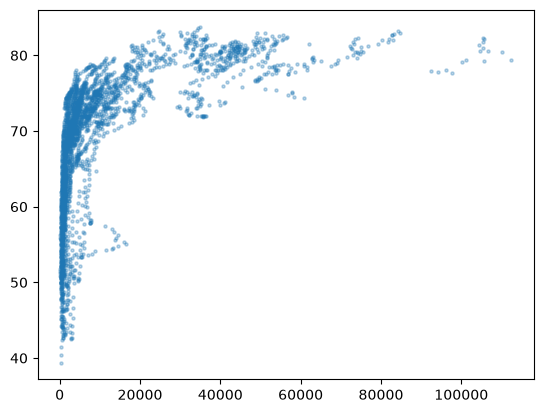

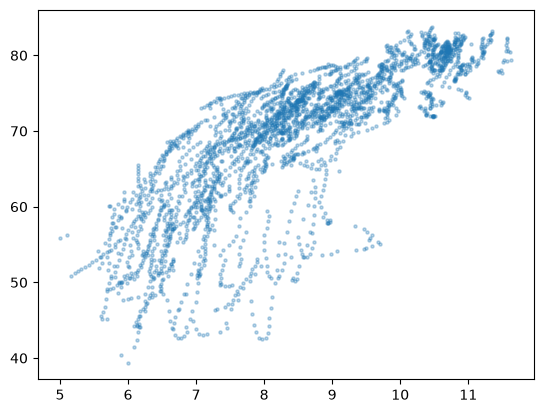

In [64]:
col = 'GDP_per_capita'

plt.scatter(df[col], df['Life_expectancy'], s=5, alpha=0.3)
plt.show()

plt.scatter(np.log1p(df[col]), df['Life_expectancy'], s=5, alpha=0.3)
plt.show()

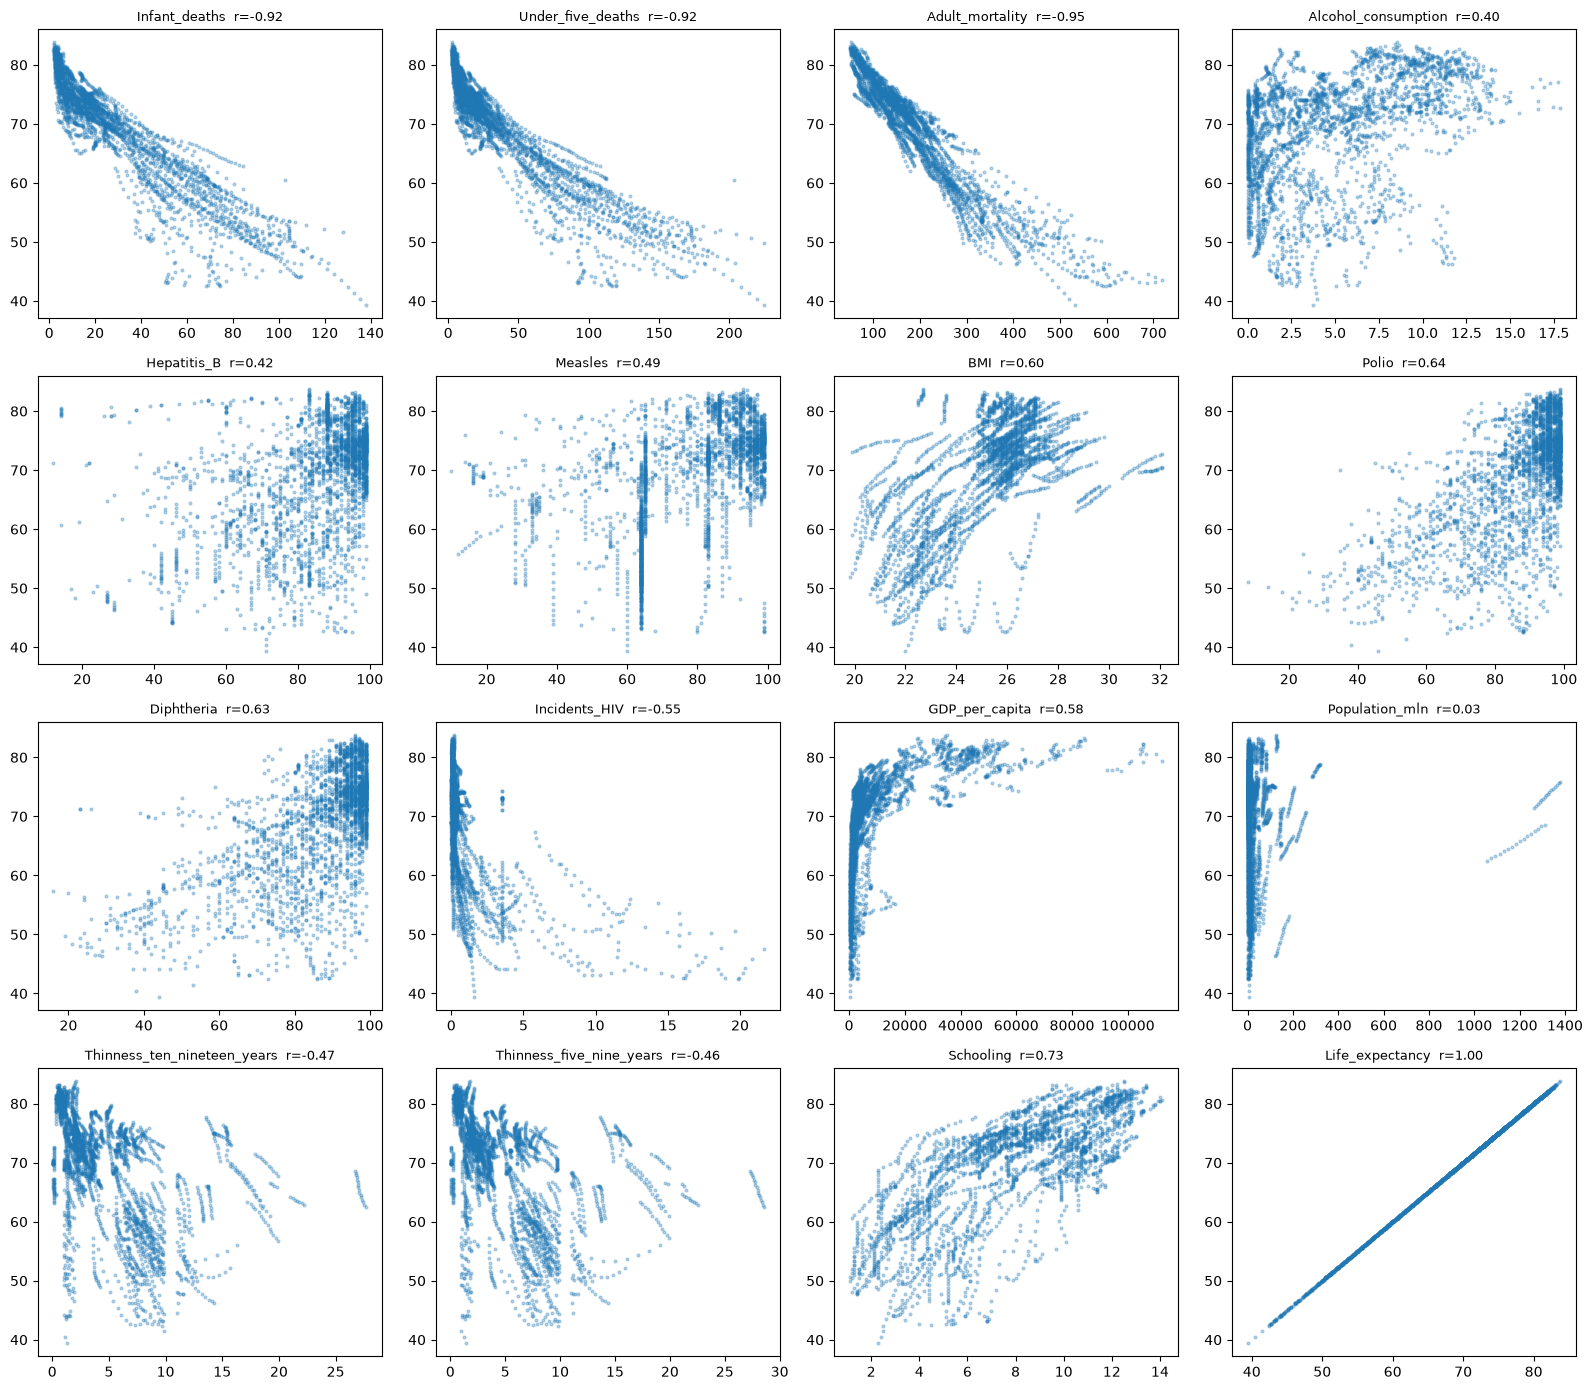

In [65]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))

for ax, col in zip(axes.flat, num_cols):
    ax.scatter(df[col], df['Life_expectancy'], s=4, alpha=0.3)
    ax.set_title(f'{col}  r={df[col].corr(df.Life_expectancy):.2f}', fontsize=9)

plt.tight_layout()
plt.show()

In [66]:
print(f'Before: {df.shape} -> After: {df_clean.shape}')

Before: (2864, 21) -> After: (2864, 22)


In [67]:
df_clean.head()

,Country,Year,Under_five_deaths,Adult_mortality,Alcohol_consumption,BMI,Incidents_HIV,Population_mln,Schooling,Economy_status_Developed,...,Region_Central America and Caribbean,Region_European Union,Region_Middle East,Region_North America,Region_Oceania,Region_Rest of Europe,Region_South America,Vaccination_coverage,Thinness_avg,log_GDP_per_capita
0,Turkiye,2015,13.0,105.8240,1.32,27.8,0.08,78.53,7.8,0,...,False,False,True,False,False,False,False,89.00,4.85,9.306287
1,Spain,2015,3.3,57.9025,10.35,26.0,0.09,46.44,9.7,1,...,False,True,False,False,False,False,False,96.25,0.55,10.155918
2,India,2007,67.9,201.0765,1.57,21.2,0.13,1183.21,5.0,0,...,False,False,False,False,False,False,False,56.50,27.55,6.981935
3,Guyana,2006,40.5,222.1965,5.68,25.3,0.79,0.75,7.9,0,...,False,False,False,False,False,False,True,88.00,5.60,8.330140
4,Israel,2012,4.3,57.9510,2.89,27.0,0.08,7.91,12.8,1,...,False,False,True,False,False,False,False,93.50,1.15,10.433998


# 4. Train/Test Split

In [68]:
y = df_clean['Life_expectancy']
X = df_clean.drop(columns=['Life_expectancy', 'Country'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)}   Test: {len(X_test)}   Features: {X.shape[1]}')

Train: 2291   Test: 573   Features: 20


# 5. Scaling

In [69]:
X_cols = X.columns.tolist()
X_train[X_cols].describe().loc[['min', 'max', 'mean', 'std']].T.round(1)

scalers = {'unscaled': None,
           'StandardScaler': StandardScaler(),
           'MinMaxScaler': MinMaxScaler(),
           'RobustScaler': RobustScaler()}

rows = []
for name, sc in scalers.items():
    Xtr, Xte = X_train.copy().astype(float), X_test.copy().astype(float)

    if sc is not None:
        Xtr[X_cols] = sc.fit_transform(Xtr[X_cols])   # fit on TRAIN only
        Xte[X_cols] = sc.transform(Xte[X_cols])

    lr = LinearRegression().fit(Xtr, y_train)
    pred = lr.predict(Xte)

    # condition number of the same design matrix, via StatsModels
    cond = sm.OLS(y_train, sm.add_constant(Xtr, has_constant='add')).fit().condition_number

    rows.append([name,
                 metrics.r2_score(y_test, pred),
                 metrics.root_mean_squared_error(y_test, pred),
                 metrics.mean_absolute_error(y_test, pred),
                 cond])

scaler_comparison = pd.DataFrame(rows, columns=['scaler', 'r2', 'rmse', 'mae', 'condition_no'])
scaler_comparison.round(6)

,scaler,r2,rmse,mae,condition_no
0,unscaled,0.98182,1.228339,0.9872,936290.123479
1,StandardScaler,0.98182,1.228339,0.9872,9.933049
2,MinMaxScaler,0.98182,1.228339,0.9872,39.940615
3,RobustScaler,0.98182,1.228339,0.9872,82.750801


In [70]:
scaler = StandardScaler()

X_train_s = X_train.copy().astype(float)
X_test_s  = X_test.copy().astype(float)
X_train_s[X_cols] = scaler.fit_transform(X_train_s[X_cols])
X_test_s[X_cols]  = scaler.transform(X_test_s[X_cols])

# 6. Fitting the Model

In [71]:
def fit_ols(Xtr, ytr, Xte):
    """Add the constant, fit, and return the results object plus train/test predictions."""
    Xtr = sm.add_constant(Xtr.astype(float), has_constant='add')
    Xte = sm.add_constant(Xte.astype(float), has_constant='add')[Xtr.columns]
    res = sm.OLS(ytr, Xtr).fit()
    return res, res.predict(Xtr), res.predict(Xte)

res_full, ptr_full, pte_full = fit_ols(X_train_s, y_train, X_test_s)
print('Train R-squared      :', round(res_full.rsquared, 4))
print('Adjusted R-squared   :', round(res_full.rsquared_adj, 4))
print('Condition number     : %.4g' % res_full.condition_number)

Train R-squared      : 0.984
Adjusted R-squared   : 0.9838
Condition number     : 9.933


In [72]:
design = sm.add_constant(X_train_s.astype(float), has_constant='add')
print('columns:', design.shape[1], ' rank:', np.linalg.matrix_rank(design.values))

columns: 21  rank: 21


In [73]:
Xv = sm.add_constant(X_train_s[X_cols].astype(float), has_constant='add')

vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
                index=Xv.columns)

vif.drop('const').sort_values(ascending=False).round(2)

# Look back and drop Under_five_deaths if applicable

Adult_mortality                         8.62
Under_five_deaths                       8.31
Economy_status_Developed                6.50
Region_European Union                   6.42
log_GDP_per_capita                      5.78
Schooling                               5.67
BMI                                     3.95
Alcohol_consumption                     3.49
Incidents_HIV                           3.20
Region_Rest of Europe                   2.61
Region_Asia                             2.51
Thinness_avg                            2.45
Vaccination_coverage                    2.43
Region_Middle East                      2.23
Region_Central America and Caribbean    2.16
Region_Oceania                          2.01
Region_South America                    1.92
Region_North America                    1.51
Population_mln                          1.19
Year                                    1.15
dtype: float64

In [74]:
c = X_train.corr()
pairs = c.where(np.triu(np.ones(c.shape), k=1).astype(bool)).stack()
pairs[pairs.abs() > 0.7].sort_values(key=abs, ascending=False)

Economy_status_Developed  Region_European Union    0.821563
Under_five_deaths         Adult_mortality          0.804864
Schooling                 log_GDP_per_capita       0.780728
Under_five_deaths         Schooling               -0.776375
                          log_GDP_per_capita      -0.763221
                          Vaccination_coverage    -0.730491
dtype: float64

# 7. Metrics

In [75]:
rmse = metrics.root_mean_squared_error(y_test, pte_full)
mae  = metrics.mean_absolute_error(y_test, pte_full)
r2   = metrics.r2_score(y_test, pte_full)

print(f'RMSE : {rmse:.3f}')
print(f'MAE  : {mae:.3f}')
print(f'R²   : {r2:.3f}')

RMSE : 1.228
MAE  : 0.987
R²   : 0.982


In [76]:
base_rmse = metrics.root_mean_squared_error(y_test, pte_full)

rows = []
for col in X_cols:
    _, _, pte = fit_ols(X_train_s.drop(columns=[col]), y_train, X_test_s.drop(columns=[col]))
    rmse = metrics.root_mean_squared_error(y_test, pte)
    rows.append([col, rmse, rmse - base_rmse])

drop_test = pd.DataFrame(rows, columns=['dropped', 'rmse', 'change'])
drop_test.sort_values('change', ascending=False).round(4)

,dropped,rmse,change
2,Adult_mortality,2.2720,1.0437
1,Under_five_deaths,1.8406,0.6122
8,Economy_status_Developed,1.2964,0.0680
10,Region_Central America and Caribbean,1.2650,0.0366
4,BMI,1.2528,0.0245
19,log_GDP_per_capita,1.2511,0.0227
14,Region_Oceania,1.2421,0.0138
16,Region_South America,1.2366,0.0083
0,Year,1.2361,0.0078
11,Region_European Union,1.2361,0.0078


# 8. Predictions and Minimal Model

In [ ]:
def predict_life_expectancy(region, year, adult_mortality, under_five_deaths,
                                     hepatitis_b, polio, diphtheria, measles,
                                     bmi, incidents_hiv, alcohol_consumption,
                                     thinness_10_19, thinness_5_9,
                                     gdp_per_capita, population_mln,
                                     schooling, economy_status_developed):

    row = {
        "Year" : year,
        "Adult_mortality" : adult_mortality,
        "Under_five_clean" : under_five_deaths,
        "Alcohol_consumption" : alcohol_consumption,
        "BMI" : bmi,
        "Incidents_HIV" : incidents_hiv,
        "Population_mln" : population_mln,
        "Schooling" : schooling,
        "Economy_status_Developed" : economy_status_developed,
        "Vaccination_coverage" : np.mean([hepatitis_b, polio, diphtheria, measles]),
        "Thinness_avg" : np.mean([thinness_10_19, thinness_5_9]),
        "log_GDP_per_capita" : np.log1p(gdp_per_capita)
    }

    row[f'Region_{region}'] = 1

    X_new = pd.DataFrame([row]).reindex(columns=X_cols, fill_value=0).astype(float)
    X_new[X_cols] = scaler.transform(X_new[X_cols])
    X_new = sm.add_constant(X_new, has_constant='add')

    return float((res_full.predict(X_new)).iloc[0])


predict_life_expectancy(
    region='Asia',
    year=2015,
    adult_mortality=223,
    under_five_deaths=13,
    hepatitis_b=97,
    polio=97,
    diphtheria=97,
    measles=65,
    bmi=26,
    incidents_hiv=0.1,
    alcohol_consumption=1.32,
    thinness_10_19=4.9,
    thinness_5_9=4.8,
    gdp_per_capita=10000,
    population_mln=78.53,
    schooling=5,
    economy_status_developed=0)


70.30765219187909

In [ ]:
REGION_COLS = [c for c in X_cols if c.startswith('Region_')]

MINIMAL = ['log_GDP_per_capita', 'Population_mln', 'Schooling',
           'Economy_status_Developed', 'Year'] + REGION_COLS

res_min, ptr_min, pte_min = fit_ols(X_train_s[MINIMAL], y_train, X_test_s[MINIMAL])
print('RMSE:', round(metrics.root_mean_squared_error(y_test, pte_min), 3))
print("")
print('MAE :', round(metrics.mean_absolute_error(y_test, pte_min), 3))
print("")
print('R²  :', round(metrics.r2_score(y_test, pte_min), 3))

RMSE: 4.548
MAE : 3.304
R²  : 0.751


In [ ]:
def predict_life_expectancy_min(region, year, gdp_per_capita, population_mln, schooling, economy_status_developed):

    rows = {
        "Year" : year,
        "Population_mln" : population_mln,
        "Schooling" : schooling,
        "Economy_status_Developed" : economy_status_developed,
        "log_GDP_per_capita" : np.log1p(gdp_per_capita)
    }
    
    row[f'Region_{region}'] = 1

    X_new = pd.DataFrame([row]).reindex(columns=X_cols, fill_value=0).astype(float)

    X_new[X_cols] = scaler.transform(X_new[X_cols])
    X_new = sm.add_constant(X_new[MINIMAL], has_constant='add')

    return float(res_min.predict(X_new).iloc[0])
    